In [12]:
import pandas as pd
import numpy as np
youtube_clean = pd.read_csv('../data/youtube_clean.csv', sep = ',')
df = youtube_clean
df

,duration,bitrate,bitrate(video),height,width,frame rate,frame rate(est.),codec,category,title,description,hashtags,views,likes,comments
0,180,5777.0,5640.0,1920,1080,25.00,25.00,h264,News & Politics,«السودان ينتفض» أمام السفارة بالقاهرة,حرية سلام وعدالة، الثورة خيار الشعب.. بهذا اله...,"في, عسكري, حكم, حرية, بخصوص, المصري اليوم, الس...",4078,41,3
1,930,1195.0,1001.0,1280,720,30.00,30.00,h264,Gaming,Pokemon Tower Defense Episodio 2,Espero que tenham gostado do video!,"Pokémon (Anime/Manga Franchise), Pokémon (Vide...",33,2,1
2,233,3028.0,2833.0,1280,720,23.98,23.98,h264,Comedy,New Hip Hop - Kemo Treats - Pancakes,Download all our music for FREE just enter $0....,"breaking bad spoof, Recipes, Pancakes, canada,...",13227,135,17
3,562,431.0,300.0,320,240,29.97,0.00,h264,People & Blogs,Sister's Keeper Impression,A Review of the Shampoo Bar(Sunburst) and Dip ...,"natural hair, first impression, sister's keepe...",43,1,0
4,300,3087.0,2929.0,1280,720,23.98,23.98,h264,Gaming,JBHAMMER777 (AKUMA) VS KtossPol Rank 1 (Vega)...,JBHAMMER777 is he strong enough to fight again...,"Tokido, momochi, (Ryu), AE, 11, at, Piyoppia, ...",222,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17581,571,1285.0,1175.0,640,480,29.92,0.00,h264,People & Blogs,rentero 1ª parte 2.MOD,No description,"rentero, latapialinares, iu, pca",27,0,0
17582,105,840.0,719.0,640,480,29.97,0.00,h264,People & Blogs,Cascavel faz campanha impecável em campeonato ...,No description,No hashtags,295,1,0
17583,161,920.0,820.0,640,480,29.97,0.00,h264,People & Blogs,Marcha para Cristo.San Francisco Menéndez. 5 ...,No description,"Cristo, Marcha, para",770,3,0
17584,291,4892.0,4738.0,1920,1080,29.97,29.97,h264,Gaming,DK Solo Steinerne Kern,"Das ist mein erstes Video, also ist noch alles...","Steinerne Kern, Vitriolsteindrachen, DK Solo, ...",42,1,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17586 entries, 0 to 17585
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   duration          17586 non-null  int64  
 1   bitrate           17586 non-null  float64
 2   bitrate(video)    17586 non-null  float64
 3   height            17586 non-null  int64  
 4   width             17586 non-null  int64  
 5   frame rate        17586 non-null  float64
 6   frame rate(est.)  17586 non-null  float64
 7   codec             17586 non-null  object 
 8   category          17586 non-null  object 
 9   title             17586 non-null  object 
 10  description       17586 non-null  object 
 11  hashtags          17586 non-null  object 
 12  views             17586 non-null  int64  
 13  likes             17586 non-null  int64  
 14  comments          17586 non-null  int64  
dtypes: float64(4), int64(6), object(5)
memory usage: 2.0+ MB


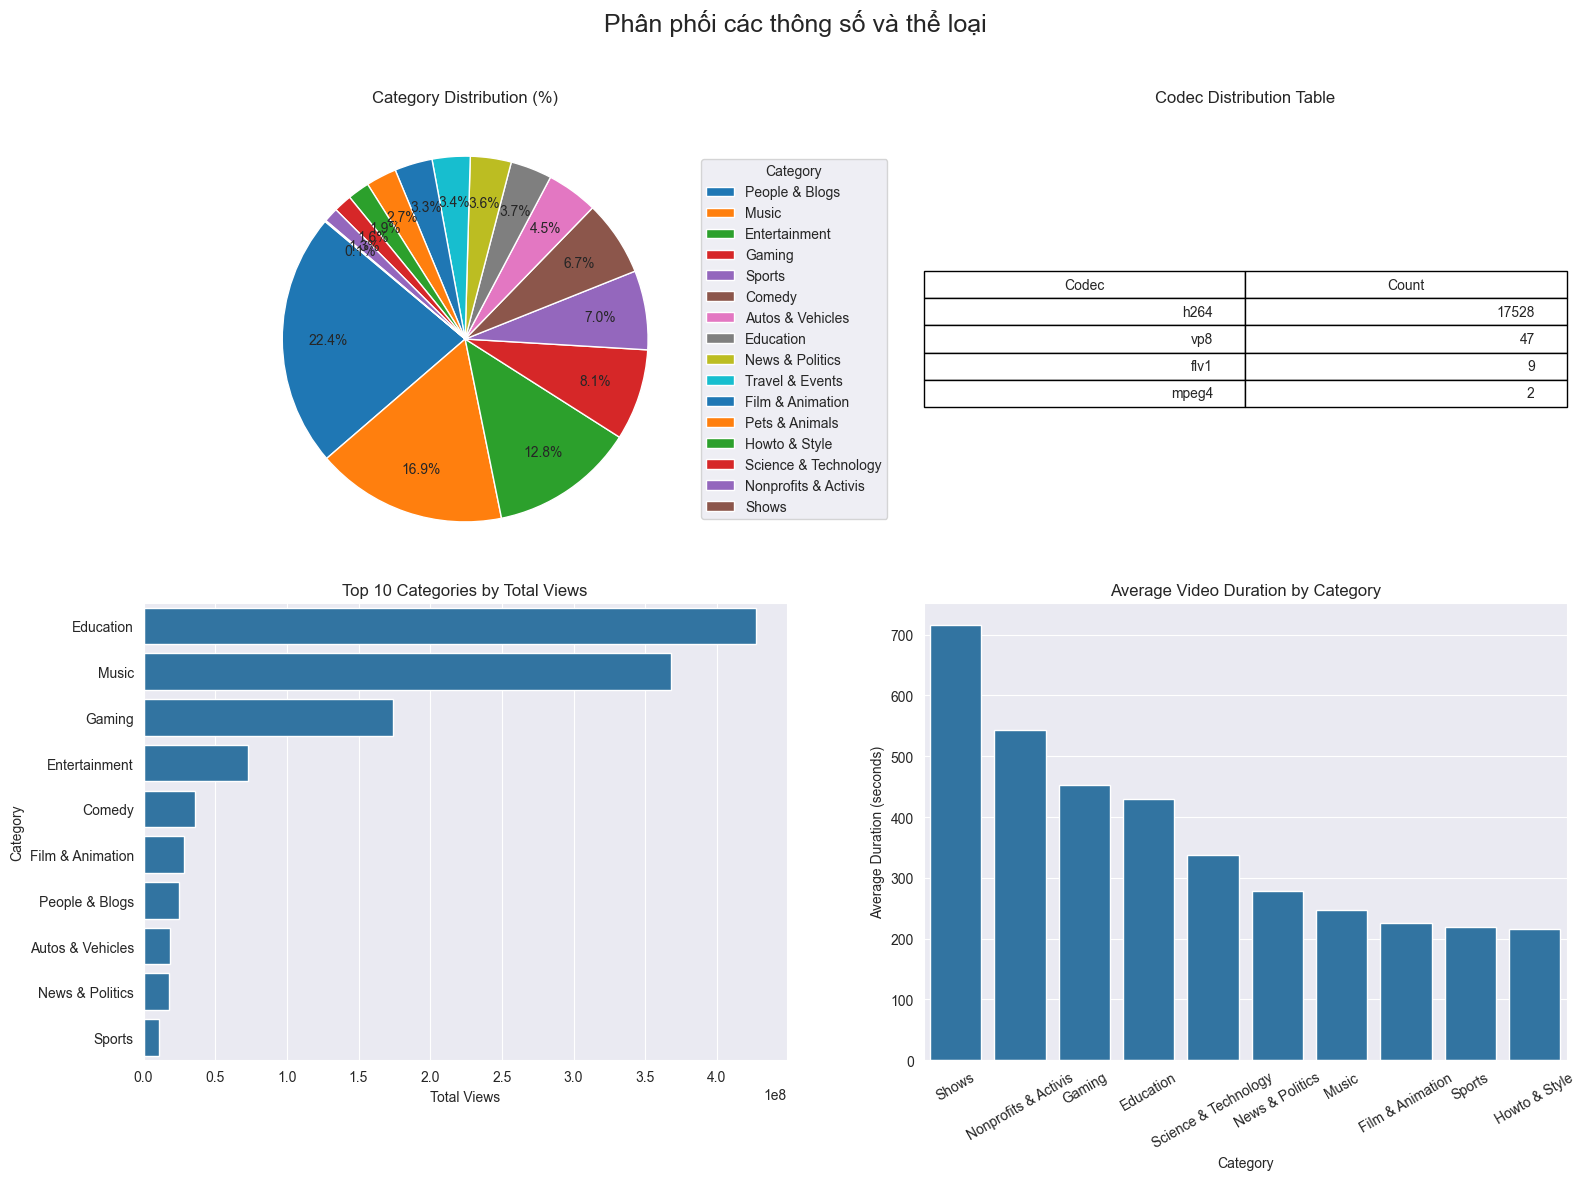

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

category_counts = df['category'].value_counts()

category_views = (
    df.groupby('category')['views']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

codec_table = (
    df['codec']
    .value_counts()
    .reset_index()
)
codec_table.columns = ['Codec', 'Count']

df['engagement_rate'] = (df['likes'] + df['comments']) / df['views']

avg_engagement = (
    df.groupby('category')['engagement_rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].pie(
    category_counts,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75
)
axes[0, 0].set_title("Category Distribution (%)")

axes[0, 0].legend(
    category_counts.index,
    title="Category",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

axes[0, 1].axis('off')
table = axes[0, 1].table(
    cellText=codec_table.values,
    colLabels=codec_table.columns,
    loc='center'
)
table.scale(1, 1.5)
axes[0, 1].set_title("Codec Distribution Table")

sns.barplot(
    x=category_views.values,
    y=category_views.index,
    orient='h',
    ax=axes[1, 0]
)
axes[1, 0].set_title("Top 10 Categories by Total Views")
axes[1, 0].set_xlabel("Total Views")
axes[1, 0].set_ylabel("Category")

sns.barplot(
    data=avg_engagement,
    x='category',
    y='duration',
    ax=axes[1, 1]
)

axes[1, 1].set_title("Average Video Duration by Category")
axes[1, 1].set_xlabel("Category")
axes[1, 1].set_ylabel("Average Duration (seconds)")
axes[1, 1].tick_params(axis='x', rotation=30)

plt.suptitle("Phân phối các thông số và thể loại", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

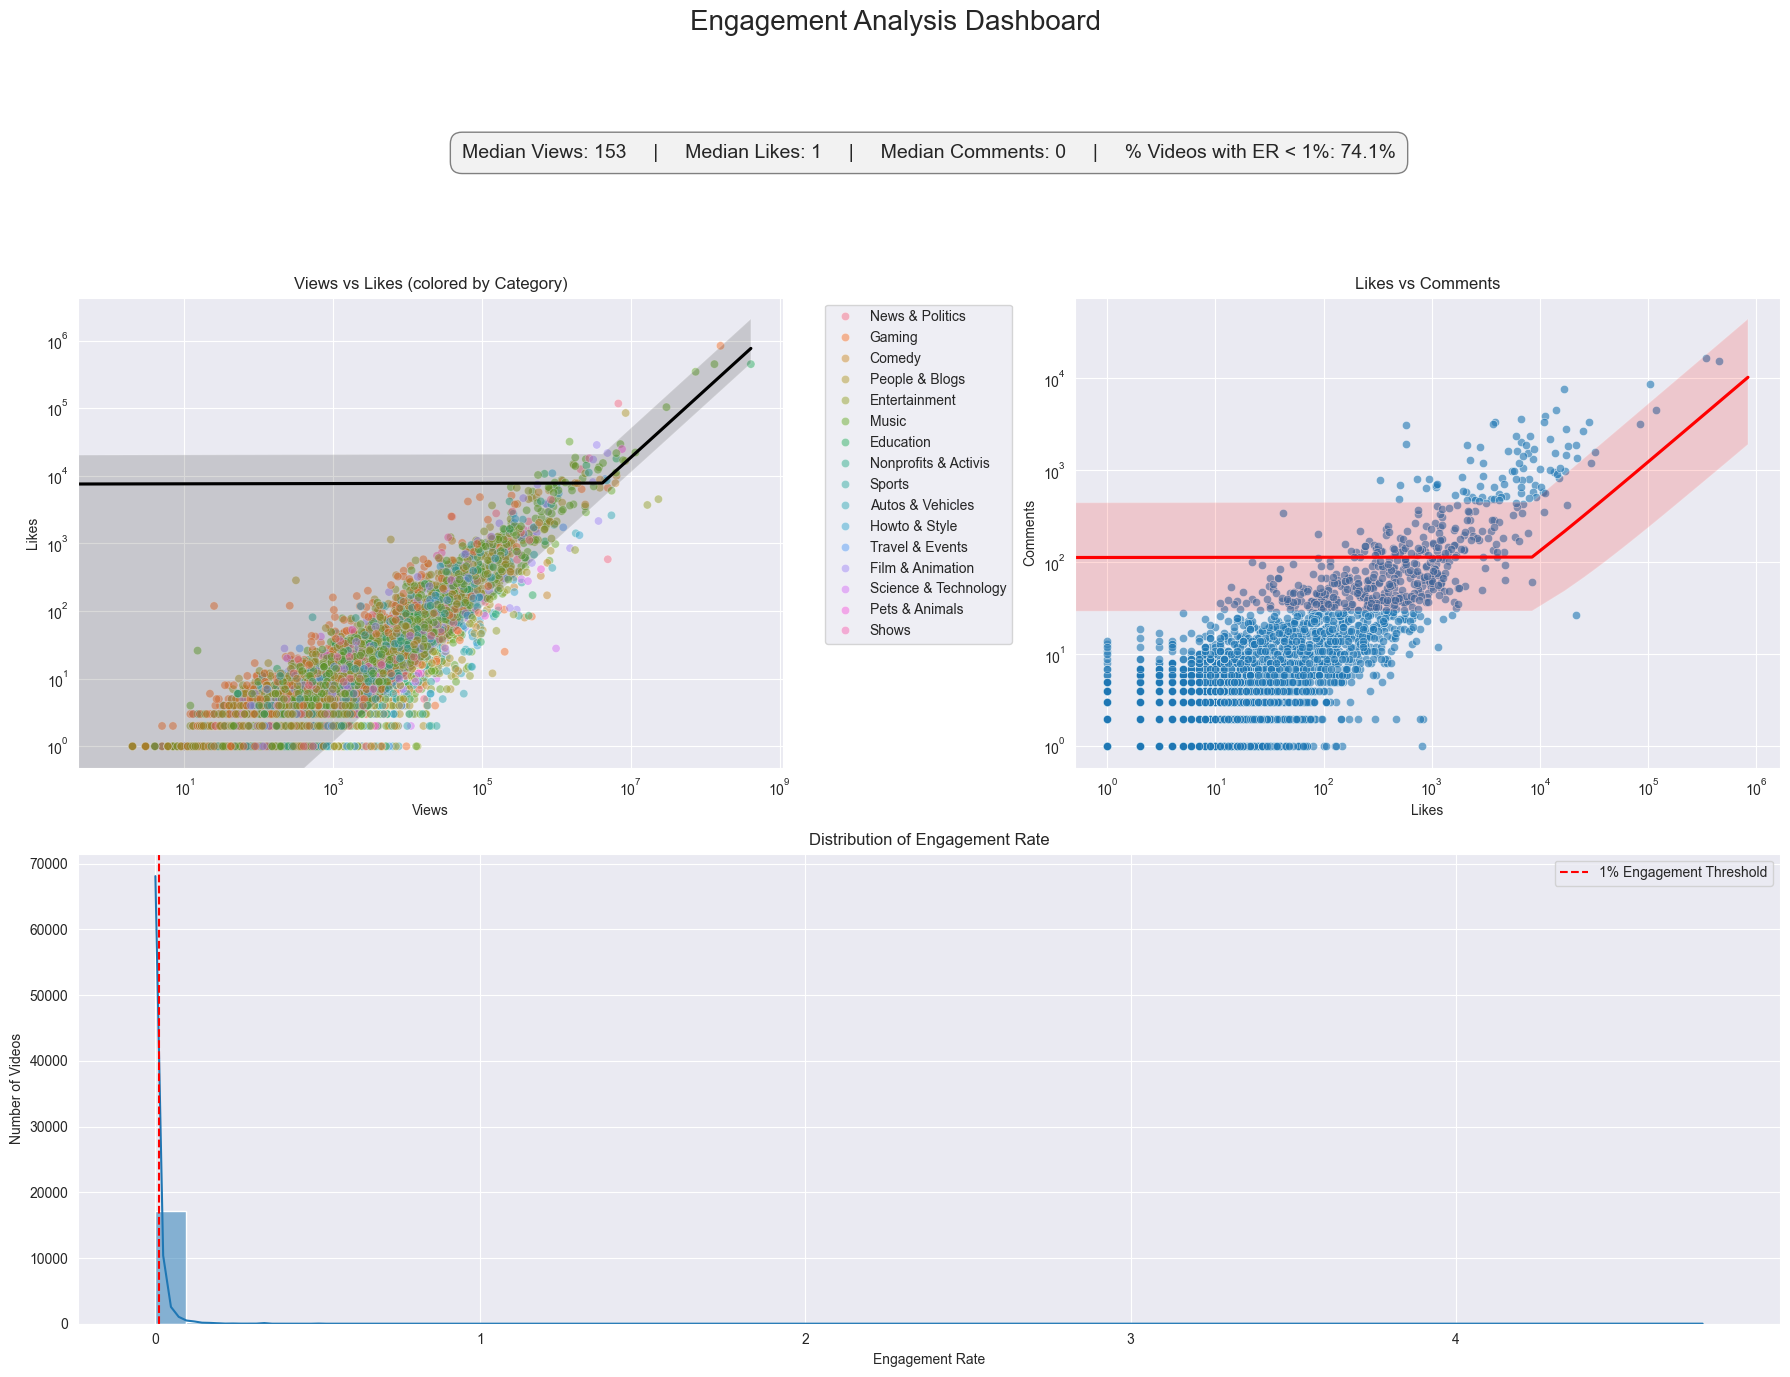

In [15]:
median_views = df['views'].median()
median_likes = df['likes'].median()
median_comments = df['comments'].median()
low_er_pct = (df['engagement_rate'] < 0.01).mean() * 100

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 4, 4])

ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')

kpi_text = (
    f"Median Views: {median_views:,.0f}     |     "
    f"Median Likes: {median_likes:,.0f}     |     "
    f"Median Comments: {median_comments:,.0f}     |     "
    f"% Videos with ER < 1%: {low_er_pct:.1f}%"
)

ax_kpi.text(
    0.5, 0.5,
    kpi_text,
    ha='center',
    va='center',
    fontsize=14,
    bbox=dict(boxstyle="round,pad=0.6", fc="#F2F2F2", ec="gray")
)

ax1 = fig.add_subplot(gs[1, 0])

sns.scatterplot(
    data=df,
    x='views',
    y='likes',
    hue='category',
    alpha=0.5,
    ax=ax1
)

sns.regplot(
    data=df,
    x='views',
    y='likes',
    scatter=False,
    color='black',
    ax=ax1
)

ax1.set_title("Views vs Likes (colored by Category)")
ax1.set_xlabel("Views")
ax1.set_ylabel("Likes")
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax2 = fig.add_subplot(gs[1, 1])

sns.scatterplot(
    data=df,
    x='likes',
    y='comments',
    alpha=0.6,
    ax=ax2
)

sns.regplot(
    data=df,
    x='likes',
    y='comments',
    scatter=False,
    color='red',
    ax=ax2
)

ax2.set_title("Likes vs Comments")
ax2.set_xlabel("Likes")
ax2.set_ylabel("Comments")
ax2.set_xscale('log')
ax2.set_yscale('log')

ax3 = fig.add_subplot(gs[2, :])

sns.histplot(
    df['engagement_rate'],
    bins=50,
    kde=True,
    ax=ax3
)

ax3.axvline(
    0.01,
    color='red',
    linestyle='--',
    label='1% Engagement Threshold'
)

ax3.set_title("Distribution of Engagement Rate")
ax3.set_xlabel("Engagement Rate")
ax3.set_ylabel("Number of Videos")
ax3.legend()

plt.suptitle("Engagement Analysis Dashboard", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()